In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [2]:
# --- Configuration ---
SEQ_LENGTH = 4000
HMM_CONCEPTS = ['A', 'B', 'C']  # 3 tokens for Mess3 HMM


In [3]:
# --- Create HMM and generate sequence with hidden states ---
from src.hmm.hmm import Mess3HMM

hmm = Mess3HMM()
hmm.create_hmm(x=0.05, alpha=0.85)

# Create emission matrix: emission_probs[state, token] = P(emit token | in state)
# T_3d_matrix has shape (vocab_size, n_states, n_states)
# T_3d_matrix[token, from_state, to_state] = P(emit token, go to to_state | in from_state)
# Sum over to_states to get emission probs
emission_matrix = hmm.T_3d_matrix.sum(dim=2).T  # Shape: (n_states, vocab_size) = (3, 3)
emission_matrix = emission_matrix / emission_matrix.sum(dim=1, keepdim=True)  # Normalize

print("Emission matrix (rows=states, cols=tokens A,B,C):")
print(emission_matrix)
print(f"\nRow sums (should be 1): {emission_matrix.sum(dim=1)}")


Emission matrix (rows=states, cols=tokens A,B,C):
tensor([[0.7725, 0.1137, 0.1137],
        [0.1138, 0.7725, 0.1138],
        [0.1137, 0.1137, 0.7725]], device='cuda:0')

Row sums (should be 1): tensor([1., 1., 1.], device='cuda:0')


In [4]:
# --- Generate HMM sequence WITH hidden states ---
# Modified generate to also return state sequence

def generate_hmm_with_states(hmm, seq_length):
    """Generate a single HMM sequence and track hidden states."""
    vocab_size, n_states, _ = hmm.T_3d_matrix.shape
    device = hmm.T_3d_matrix.device
    
    prior = torch.ones(n_states, dtype=torch.float, device=device) / n_states
    
    tokens = torch.zeros(seq_length, dtype=torch.int64, device=device)
    states = torch.zeros(seq_length, dtype=torch.int64, device=device)  # Track hidden states
    
    # Sample initial state
    state_idx = torch.multinomial(prior, 1).item()
    
    for i in range(seq_length):
        # Store current state
        states[i] = state_idx
        
        # Get transition probs for current state: T_3d_matrix[:, :, state_idx]
        # Shape: (vocab_size, n_states) - all (token, next_state) pairs
        trans_probs = hmm.T_3d_matrix[:, :, state_idx].flatten()  # (vocab_size * n_states,)
        
        # Sample (token, next_state) pair
        pair_idx = torch.multinomial(trans_probs, 1).item()
        
        # Decode token and next state
        tokens[i] = pair_idx % vocab_size
        state_idx = pair_idx // vocab_size
    
    return tokens, states

# Generate sequence
tokens, hidden_states = generate_hmm_with_states(hmm, SEQ_LENGTH)

# Convert to concept strings
walk_concepts = [HMM_CONCEPTS[t.item()] for t in tokens]

print(f"Sequence length: {len(tokens)}")
print(f"First 20 tokens: {walk_concepts[:20]}")
print(f"First 20 states: {hidden_states[:20].tolist()}")
print(f"\nToken distribution: A={walk_concepts.count('A')}, B={walk_concepts.count('B')}, C={walk_concepts.count('C')}")


Sequence length: 4000
First 20 tokens: ['B', 'B', 'B', 'C', 'A', 'B', 'A', 'A', 'A', 'B', 'C', 'B', 'B', 'B', 'C', 'A', 'A', 'A', 'B', 'A']
First 20 states: [1, 1, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0]

Token distribution: A=1421, B=1218, C=1361


In [5]:
# --- Load LLM ---
from src.models.llm_interface import LlamaInterface

llm = LlamaInterface("llama-3.1-8b")


Loading llama-3.1-8b on cuda...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully! Layers: 32


In [6]:
# --- Helper function ---
def get_concept_token_ids(llm, concepts):
    """Get the token IDs for each concept (with space prefix)."""
    concept_to_id = {}
    for concept in concepts:
        spaced = f" {concept}"
        ids, tokens = llm.tokenize(spaced)
        concept_to_id[concept] = ids[-1]
    return concept_to_id


In [7]:
# --- Single forward pass to get all logits ---
print("Running single forward pass...")

# Get concept token IDs for A, B, C
concept_to_id = get_concept_token_ids(llm, HMM_CONCEPTS)
concept_ids = torch.tensor([concept_to_id[c] for c in HMM_CONCEPTS])

print(f"Concept token IDs: {concept_to_id}")

# Tokenize the sequence
text = " ".join(walk_concepts)
inputs = llm.tokenizer(text, return_tensors="pt").to(llm.device)
input_ids = inputs.input_ids[0]

print(f"Input sequence length (tokens): {len(input_ids)}")

# Forward pass
with torch.no_grad():
    outputs = llm.model(**inputs, return_dict=True)
    logits = outputs.logits[0]  # Shape: (seq_len, vocab_size)

print(f"Logits shape: {logits.shape}")

# Extract logits for A, B, C and convert to probabilities
concept_ids_device = concept_ids.to(logits.device)
concept_logits = logits[:, concept_ids_device]  # Shape: (seq_len, 3)
llm_probs = F.softmax(concept_logits, dim=1)  # Shape: (seq_len, 3)

print(f"LLM probs shape: {llm_probs.shape}")


Running single forward pass...
Concept token IDs: {'A': 362, 'B': 426, 'C': 356}
Input sequence length (tokens): 4001
Logits shape: torch.Size([4001, 128256])
LLM probs shape: torch.Size([4001, 3])


In [8]:
# --- Compute emission probability match at each position ---
# Compare LLM's predicted distribution with HMM's emission distribution given the hidden state

token_id_to_concept_idx = {concept_to_id[c]: i for i, c in enumerate(HMM_CONCEPTS)}
actual_token_ids = input_ids[1:]  # Tokens we're predicting (shifted by 1)

# Move emission matrix to same device as llm_probs
emission_matrix_device = emission_matrix.to(llm_probs.device)

emission_prob_matches = []  # Dot product of LLM probs with HMM emission probs
positions = []
state_ids = []

for i, token_id in enumerate(actual_token_ids.tolist()):
    if token_id in token_id_to_concept_idx:
        # Get hidden state at position i (the state BEFORE emitting token i+1)
        state_idx = hidden_states[i].item()
        
        # Get HMM emission distribution for this state
        hmm_emission_probs = emission_matrix_device[state_idx]  # Shape: (3,)
        
        # Get LLM's predicted distribution at position i (predicting token i+1)
        llm_pred_probs = llm_probs[i]  # Shape: (3,)
        
        # Compute match: dot product (how much LLM agrees with HMM emission dist)
        # This equals sum of LLM probs weighted by HMM emission probs
        match = (llm_pred_probs * hmm_emission_probs).sum().item()
        
        emission_prob_matches.append(match)
        positions.append(i)
        state_ids.append(state_idx)

# Convert to arrays
positions = np.array(positions)
emission_prob_matches = np.array(emission_prob_matches)
state_ids = np.array(state_ids)

# Compute running average
running_avg = np.cumsum(emission_prob_matches) / np.arange(1, len(emission_prob_matches) + 1)

print(f"Valid positions: {len(positions)}")
print(f"Mean emission match: {np.mean(emission_prob_matches):.4f}")

Valid positions: 3999
Mean emission match: 0.4749


In [9]:
# --- Show sample positions ---
print("--- Sample positions ---")
print("Emission matrix per state:")
for s in range(3):
    print(f"  State {s}: A={emission_matrix[s,0]:.3f}, B={emission_matrix[s,1]:.3f}, C={emission_matrix[s,2]:.3f}")

print("\n--- Sample predictions ---")
for target_pos in [5, 100, 500, 1000, 2000, 3000]:
    if target_pos in positions:
        idx = np.where(positions == target_pos)[0][0]
        state = state_ids[idx]
        match = emission_prob_matches[idx]
        hmm_probs = emission_matrix[state].cpu().numpy()
        llm_pred = llm_probs[target_pos].cpu().numpy()
        print(f"Position {target_pos}: State={state}, Match={match:.4f}")
        print(f"  HMM emission: A={hmm_probs[0]:.3f}, B={hmm_probs[1]:.3f}, C={hmm_probs[2]:.3f}")
        print(f"  LLM predicts: A={llm_pred[0]:.3f}, B={llm_pred[1]:.3f}, C={llm_pred[2]:.3f}")

--- Sample positions ---
Emission matrix per state:
  State 0: A=0.773, B=0.114, C=0.114
  State 1: A=0.114, B=0.773, C=0.114
  State 2: A=0.114, B=0.114, C=0.773

--- Sample predictions ---
Position 5: State=0, Match=0.4605
  HMM emission: A=0.773, B=0.114, C=0.114
  LLM predicts: A=0.526, B=0.309, C=0.164
Position 100: State=0, Match=0.6525
  HMM emission: A=0.773, B=0.114, C=0.114
  LLM predicts: A=0.818, B=0.134, C=0.048
Position 500: State=1, Match=0.4592
  HMM emission: A=0.114, B=0.773, C=0.114
  LLM predicts: A=0.318, B=0.524, C=0.157
Position 1000: State=0, Match=0.5535
  HMM emission: A=0.773, B=0.114, C=0.114
  LLM predicts: A=0.667, B=0.188, C=0.144
Position 2000: State=1, Match=0.2390
  HMM emission: A=0.114, B=0.773, C=0.114
  LLM predicts: A=0.685, B=0.190, C=0.125
Position 3000: State=0, Match=0.4290
  HMM emission: A=0.773, B=0.114, C=0.114
  LLM predicts: A=0.479, B=0.187, C=0.334


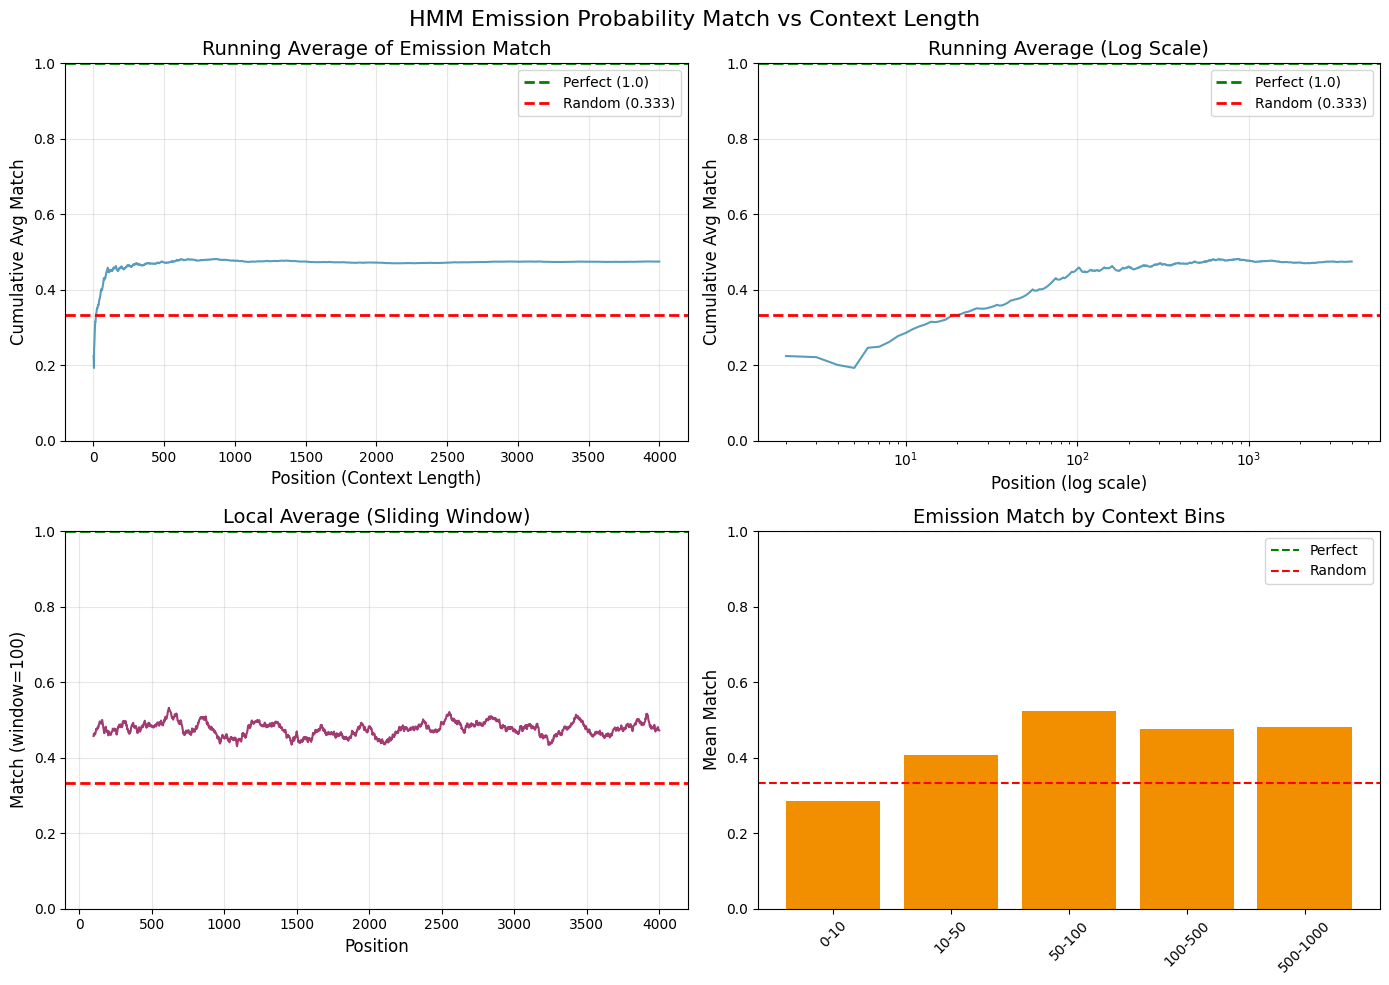


Final average emission match: 0.4749
Random baseline (1/3): 0.3333


In [10]:
# --- Plot emission match vs context length ---

# Random baseline: uniform LLM probs would give 1/3 match with any emission dist
random_baseline = 1/3

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HMM Emission Probability Match vs Context Length', fontsize=16)

# Plot 1: Running average
ax1 = axes[0, 0]
ax1.plot(positions, running_avg, linewidth=1.5, color='#2E86AB', alpha=0.8)
ax1.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
ax1.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2, label=f'Random ({random_baseline:.3f})')
ax1.set_xlabel('Position (Context Length)', fontsize=12)
ax1.set_ylabel('Cumulative Avg Match', fontsize=12)
ax1.set_title('Running Average of Emission Match', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Plot 2: Log scale x-axis
ax2 = axes[0, 1]
ax2.semilogx(positions + 1, running_avg, linewidth=1.5, color='#2E86AB', alpha=0.8)
ax2.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
ax2.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2, label=f'Random ({random_baseline:.3f})')
ax2.set_xlabel('Position (log scale)', fontsize=12)
ax2.set_ylabel('Cumulative Avg Match', fontsize=12)
ax2.set_title('Running Average (Log Scale)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# Plot 3: Sliding window average
window = 100
if len(emission_prob_matches) > window:
    slide_avg = np.convolve(emission_prob_matches, np.ones(window)/window, mode='valid')
    ax3 = axes[1, 0]
    ax3.plot(positions[window-1:], slide_avg, linewidth=1.5, color='#A23B72')
    ax3.axhline(y=1.0, color='green', linestyle='--', linewidth=2)
    ax3.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Position', fontsize=12)
    ax3.set_ylabel(f'Match (window={window})', fontsize=12)
    ax3.set_title('Local Average (Sliding Window)', fontsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)

# Plot 4: Binned average
bins = [0, 10, 50, 100, 500, 1000, 5000]
bins = [b for b in bins if b <= max(positions)]
avgs, labels = [], []
for i in range(len(bins)-1):
    m = (positions >= bins[i]) & (positions < bins[i+1])
    if np.any(m):
        avgs.append(np.mean(emission_prob_matches[m]))
        labels.append(f'{bins[i]}-{bins[i+1]}')
ax4 = axes[1, 1]
ax4.bar(range(len(avgs)), avgs, color='#F18F01')
ax4.axhline(y=1.0, color='green', linestyle='--', label='Perfect')
ax4.axhline(y=random_baseline, color='red', linestyle='--', label='Random')
ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels(labels, rotation=45)
ax4.set_ylabel('Mean Match', fontsize=12)
ax4.set_title('Emission Match by Context Bins', fontsize=14)
ax4.set_ylim(0, 1)
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal average emission match: {running_avg[-1]:.4f}")
print(f"Random baseline (1/3): {random_baseline:.4f}")
